# Restaurant Review Sentiment Classifier

## Projenin Amacı

Bu projenin amacı, restoran yorumlarını kullanarak bir yorumun olumlu mu yoksa olumsuz mu olduğunu tahmin etmektir.

Bu çalışmada NLP yani doğal dil işleme yöntemleri kullanılacaktır. Yorum metinleri temizlenecek, sayısal hale getirilecek ve en az üç farklı makine öğrenmesi modeli ile sınıflandırma yapılacaktır.

## Yol Haritası

1. Proje görselini ve veri setini tanıtma
2. Veri setini okuma ve ilk inceleme
3. Yorum metinlerini temizleme
4. Görselleştirme ve word cloud oluşturma
5. En az üç farklı model eğitme
6. Modellerin başarılarını karşılaştırma
7. Sonuçları değerlendirme


In [51]:
# Bu hücrede Kaggle'a yüklenen proje dosyalarının bulunduğu klasör yolunu tanımlıyoruz.
# Daha sonra bu klasördeki dosyaları kontrol ediyoruz.

DATA_PATH = '/kaggle/input/datasets/hakankahraman571/restaurant-sentiment-analysis-data'
os.listdir(DATA_PATH)


['cloud (1).png',
 'original_Bacchanal-Buffet-at-Caesars-Palace.jpg',
 'NLP_Sentiment-Analysis.pdf',
 'restaurant.csv',
 'wc.png']

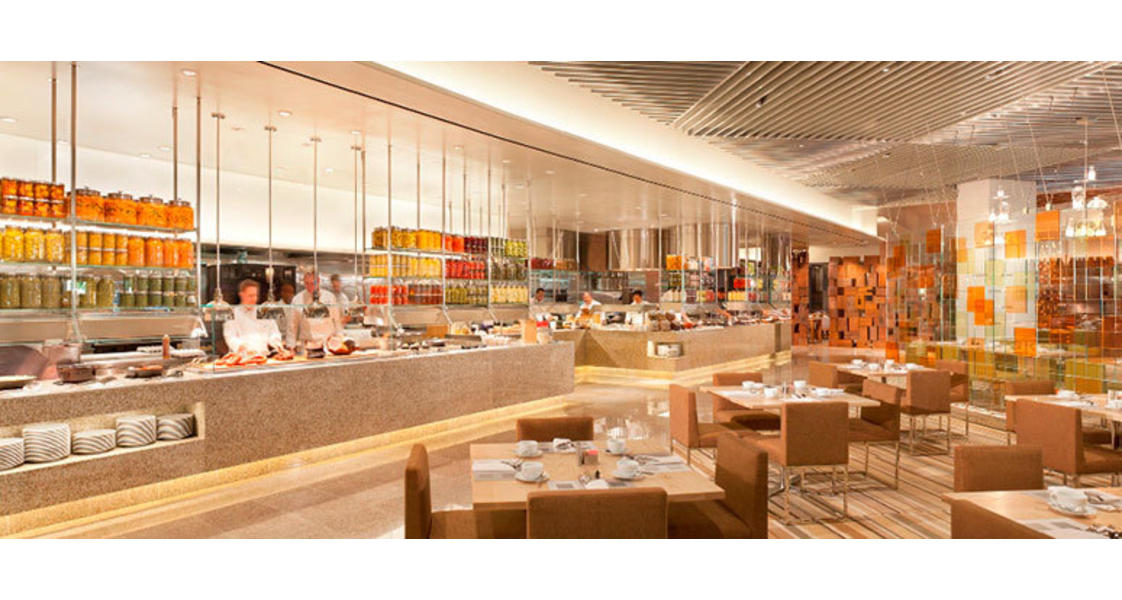

In [52]:
# Bu hücrede proje konusuna uygun restoran görselini notebook içinde gösteriyoruz.
# Görsel, proje giriş bölümünü daha anlaşılır ve dikkat çekici hale getirir.

from IPython.display import Image, display

display(Image(filename=DATA_PATH + '/original_Bacchanal-Buffet-at-Caesars-Palace.jpg', width=700))


In [53]:
# Bu hücrede veri setini okuyoruz ve ilk satırları inceleyerek veri yapısını kontrol ediyoruz.

import pandas as pd

df = pd.read_csv(DATA_PATH + '/restaurant.csv')
df.head()


,Unnamed: 0,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,2370338,_WTGv5XnA-qb_XD1D7Z0jg,6PgdGb3HrZdsfl2GiULo8w,RESDUcs7fIiihp38-d6_6g,5,0,1,0,After getting food poisoning at the Palms hote...,2012-12-04 03:10:18
1,2370357,JlNnsvMPLK_1-X2hwzK24w,IS9yw8P2uAPBX6FNLLX4KA,RESDUcs7fIiihp38-d6_6g,4,39,21,29,"""A feast worthy of Gods""\n\nBaccarnal Buffet i...",2014-01-17 00:50:50
2,2370373,hBkoWffORRb6aqKhC_Li2A,uZdFsE_aHbFBChgN6Xa8tw,RESDUcs7fIiihp38-d6_6g,4,1,1,1,The crab legs are better than the ones at Wick...,2015-06-08 18:03:09
3,2370411,rbkxvrgZg5kdCL2a66QYmA,8ZWJNAEWsymXDzKx3B0tTQ,RESDUcs7fIiihp38-d6_6g,1,0,0,0,Not worth it! Too salty food and expensive! Th...,2016-12-19 16:15:29
4,2370500,5tw_pedoHVi9bgeiBNsISg,E0sm4Ve7ifanFYeQMcV8Eg,RESDUcs7fIiihp38-d6_6g,5,0,0,0,I would give this infinite stars if I could. M...,2015-07-28 07:13:17


In [54]:
# Bu hücrede veri setinden sadece gerekli sütunları seçiyoruz.
# text sütunu yorumları, stars sütunu ise verilen yıldız puanını gösterir.
# Daha sonra yıldız puanına göre positive, negative veya neutral duygu etiketi oluşturuyoruz.

df = df[['text', 'stars']].dropna()

df['sentiment'] = df['stars'].apply(
    lambda x: 'positive' if x >= 4 else 'negative' if x <= 2 else 'neutral'
)

df.head()


,text,stars,sentiment
0,After getting food poisoning at the Palms hote...,5,positive
1,"""A feast worthy of Gods""\n\nBaccarnal Buffet i...",4,positive
2,The crab legs are better than the ones at Wick...,4,positive
3,Not worth it! Too salty food and expensive! Th...,1,negative
4,I would give this infinite stars if I could. M...,5,positive


## Veri Setinin Hazırlanması

Bu bölümde veri setinden proje için gerekli olan iki sütun seçilmiştir: yorum metni ve yıldız puanı.

Yıldız puanı kullanılarak yeni bir duygu etiketi oluşturulmuştur:

- 4 ve 5 yıldız alan yorumlar: positive
- 1 ve 2 yıldız alan yorumlar: negative
- 3 yıldız alan yorumlar: neutral

Böylece makine öğrenmesi modellerinin tahmin etmeye çalışacağı hedef değişken hazırlanmıştır.


In [55]:
# Bu hücrede veri setinin kaç yorumdan oluştuğunu
# ve her duygu sınıfında kaç yorum olduğunu inceliyoruz.

print("Toplam yorum sayısı:", len(df))
df['sentiment'].value_counts()


Toplam yorum sayısı: 10417


sentiment
positive    6883
negative    1973
neutral     1561
Name: count, dtype: int64

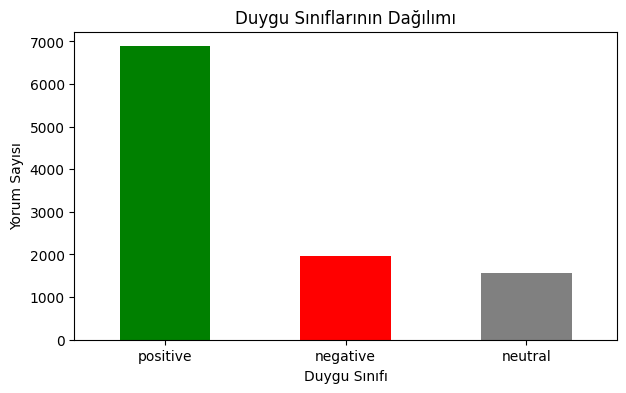

In [56]:
# Bu hücrede duygu sınıflarının dağılımını grafikle gösteriyoruz.
# Böylece veri setinde hangi duygu türünden kaç yorum olduğunu daha kolay görüyoruz.

import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(7,4))
sentiment_counts.plot(kind='bar', color=['green', 'red', 'gray'])
plt.title('Duygu Sınıflarının Dağılımı')
plt.xlabel('Duygu Sınıfı')
plt.ylabel('Yorum Sayısı')
plt.xticks(rotation=0)
plt.show()


## Duygu Dağılımı Yorumu

Grafikte görüldüğü gibi veri setinde en fazla positive yorum bulunmaktadır. Negative ve neutral yorumlar daha az sayıdadır.

Bu durum bize veri setinin tamamen dengeli olmadığını gösterir. Yine de üç duygu sınıfı da veri içinde bulunduğu için sınıflandırma modeli kurulabilir.


## Metin Temizleme

Yorum metinleri doğrudan modele verilmeden önce temizlenmelidir.

Bu bölümde metinler küçük harfe çevrilecek, noktalama işaretleri ve gereksiz karakterler temizlenecektir. Böylece modeller daha düzenli bir metin üzerinde çalışacaktır.


In [57]:
# Bu hücrede yorum metinlerini temizlemek için küçük bir fonksiyon yazıyoruz.
# Metinleri küçük harfe çeviriyoruz ve harf olmayan karakterleri temizliyoruz.

import re

def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-z ]', ' ', text)
    text = re.sub(' +', ' ', text)
    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()


,text,clean_text
0,After getting food poisoning at the Palms hote...,after getting food poisoning at the palms hote...
1,"""A feast worthy of Gods""\n\nBaccarnal Buffet i...",a feast worthy of gods baccarnal buffet in cae...
2,The crab legs are better than the ones at Wick...,the crab legs are better than the ones at wick...
3,Not worth it! Too salty food and expensive! Th...,not worth it too salty food and expensive this...
4,I would give this infinite stars if I could. M...,i would give this infinite stars if i could my...


Metin temizleme sonucunda yorumlar daha sade hale getirilmiştir. Büyük harfler küçük harfe çevrilmiş, noktalama işaretleri ve gereksiz karakterler kaldırılmıştır.

Bu işlem modelin aynı kelimeleri farklı biçimlerde görmesini azaltır. Örneğin `Good`, `good` ve `good!` ifadeleri temizleme sonrasında aynı yapıya yaklaşır.


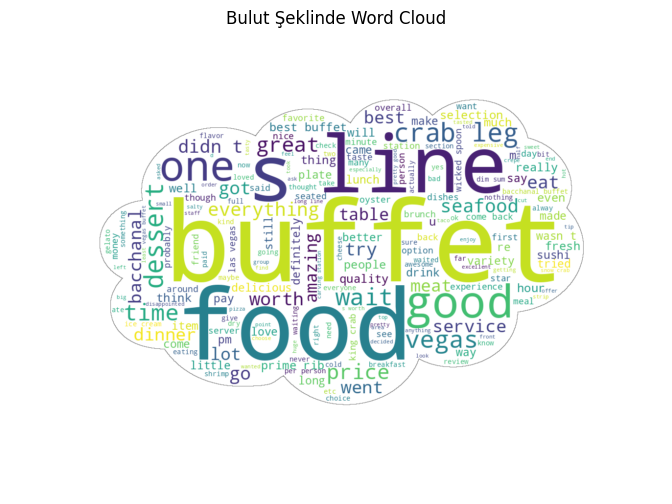

In [58]:
# Bu hücrede cloud görselini maske olarak kullanarak bulut şeklinde word cloud oluşturuyoruz.
# Böylece kelimeler dikdörtgen yerine bulut görselinin içine yerleşir.

import numpy as np
from PIL import Image as PILImage

cloud_mask = np.array(PILImage.open(DATA_PATH + '/cloud (1).png'))

wordcloud_cloud = WordCloud(
    width=900,
    height=500,
    background_color='white',
    stopwords=stop_words,
    mask=cloud_mask,
    contour_width=1,
    contour_color='gray'
).generate(all_words)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud_cloud, interpolation='bilinear')
plt.axis('off')
plt.title('Bulut Şeklinde Word Cloud')
plt.show()


## Bulut Şeklinde Word Cloud Yorumu

Bu görselde temizlenmiş yorumlardaki en sık kullanılan kelimeler bulut şeklinde gösterilmiştir.

En büyük kelimeler, veri setinde en çok tekrar eden kelimelerdir. `food`, `buffet`, `line`, `good`, `service`, `dessert` ve `price` gibi kelimelerin öne çıkması, restoran yorumlarında yemek, servis, fiyat ve bekleme süresi konularının önemli olduğunu göstermektedir.



## Modelleme Hazırlığı

Bu bölümde temizlenmiş yorumlar makine öğrenmesi modelleri için hazırlanacaktır.

Yorum metinleri doğrudan sayısal olmadığı için önce TF-IDF yöntemi ile sayısal hale getirilecektir. Daha sonra veri seti eğitim ve test verisi olarak ikiye ayrılacaktır.

Eğitim verisi modele öğretmek için, test verisi ise modelin başarısını ölçmek için kullanılacaktır.


In [59]:
# Bu hücrede yorum metinlerini ve duygu etiketlerini ayırıyoruz.
# Daha sonra veriyi eğitim ve test olarak iki parçaya bölüyoruz.

from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Eğitim verisi:", X_train.shape[0])
print("Test verisi:", X_test.shape[0])


Eğitim verisi: 8333
Test verisi: 2084


In [60]:
# Bu hücrede metinleri TF-IDF yöntemi ile sayısal hale getiriyoruz.
# Böylece makine öğrenmesi modelleri yorum metinlerini kullanabilir.

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Eğitim veri boyutu:", X_train_tfidf.shape)
print("Test veri boyutu:", X_test_tfidf.shape)


Eğitim veri boyutu: (8333, 5000)
Test veri boyutu: (2084, 5000)


## Makine Öğrenmesi Modelleri

Bu bölümde aynı veri seti üzerinde üç farklı sınıflandırma modeli eğitilecektir.

Kullanılacak modeller:

1. Logistic Regression
2. Multinomial Naive Bayes
3. Linear SVM

Bu üç modelin başarıları karşılaştırılarak restoran yorumlarını sınıflandırmada hangi modelin daha başarılı olduğu incelenecektir.


In [61]:
# Bu hücrede üç farklı makine öğrenmesi modelini eğitiyoruz.
# Her modelin test verisi üzerindeki doğruluk başarısını hesaplıyoruz.

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    prediction = model.predict(X_test_tfidf)
    results[name] = accuracy_score(y_test, prediction)

results


{'Logistic Regression': 0.8152591170825336,
 'Naive Bayes': 0.7154510556621881,
 'Linear SVM': 0.8080614203454894}

In [62]:
# Bu hücrede modellerin doğruluk başarılarını tablo haline getiriyoruz.
# Sonuçları yüzde formatında göstererek karşılaştırmayı kolaylaştırıyoruz.

results_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy': results.values()
})

results_df['Accuracy (%)'] = results_df['Accuracy'] * 100
results_df


,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.815259,81.525912
1,Naive Bayes,0.715451,71.545106
2,Linear SVM,0.808061,80.806142


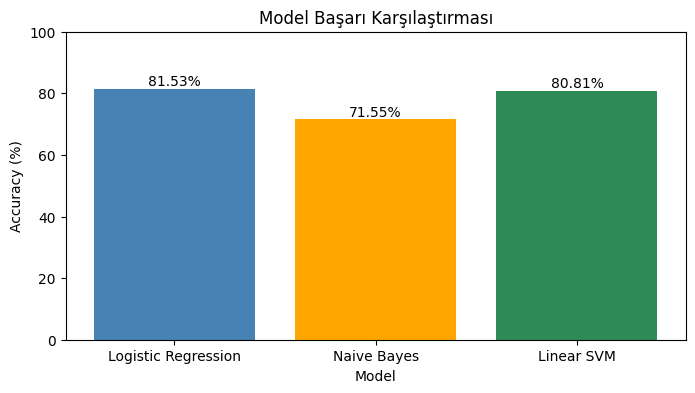

In [63]:
# Bu hücrede üç modelin başarı oranlarını grafikle karşılaştırıyoruz.
# En yüksek doğruluk değerine sahip model bu grafikte daha kolay görülebilir.

plt.figure(figsize=(8,4))
plt.bar(results_df['Model'], results_df['Accuracy (%)'], color=['steelblue', 'orange', 'seagreen'])
plt.title('Model Başarı Karşılaştırması')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

for i, value in enumerate(results_df['Accuracy (%)']):
    plt.text(i, value + 1, f"{value:.2f}%", ha='center')

plt.show()


## Model Sonuçlarının Yorumu

Üç farklı model aynı eğitim ve test verisi üzerinde denenmiştir.

Sonuçlara göre en yüksek doğruluk oranını Logistic Regression modeli vermiştir. Linear SVM modeli de Logistic Regression modeline oldukça yakın bir başarı göstermiştir. Naive Bayes modeli ise diğer iki modele göre daha düşük doğruluk oranına sahiptir.

Bu sonuçlara göre bu veri seti için en başarılı model Logistic Regression olarak seçilmiştir.


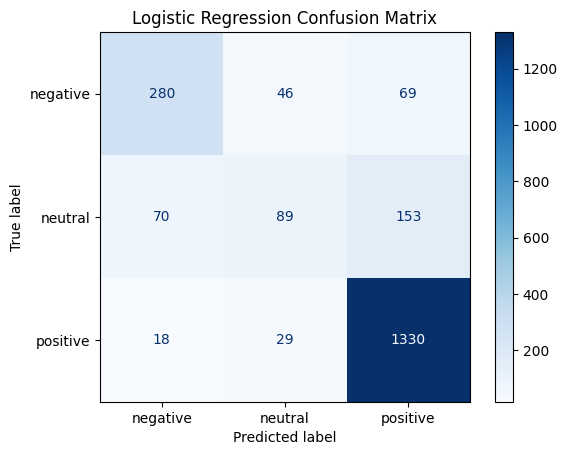

In [64]:
# Bu hücrede en başarılı model olan Logistic Regression için confusion matrix oluşturuyoruz.
# Confusion matrix, modelin hangi duygu sınıflarını doğru veya yanlış tahmin ettiğini gösterir.

from sklearn.metrics import ConfusionMatrixDisplay

best_model = models["Logistic Regression"]
best_prediction = best_model.predict(X_test_tfidf)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_prediction,
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.show()


## Confusion Matrix Yorumu

Confusion matrix sonucuna göre Logistic Regression modeli positive yorumları oldukça başarılı şekilde tahmin etmiştir. Negative yorumlarda da kabul edilebilir bir başarı vardır.

Modelin en çok zorlandığı sınıf neutral sınıfıdır. Bunun nedeni neutral yorumların bazen hem olumlu hem de olumsuz kelimeler içermesi olabilir. Ayrıca veri setinde neutral yorum sayısı positive yorumlara göre daha azdır.

Genel olarak model, özellikle positive ve negative yorumları ayırt etmede başarılıdır.



In [65]:
# Bu hücrede en başarılı model için classification report oluşturuyoruz.
# Precision, recall ve f1-score değerleri modelin her sınıftaki başarısını gösterir.

from sklearn.metrics import classification_report

print(classification_report(y_test, best_prediction))


              precision    recall  f1-score   support

    negative       0.76      0.71      0.73       395
     neutral       0.54      0.29      0.37       312
    positive       0.86      0.97      0.91      1377

    accuracy                           0.82      2084
   macro avg       0.72      0.65      0.67      2084
weighted avg       0.79      0.82      0.80      2084



## Classification Report Yorumu

Classification report sonucuna göre Logistic Regression modelinin genel doğruluk oranı yaklaşık %82'dir.

Model positive yorumları tahmin etmede oldukça başarılıdır. Positive sınıfının f1-score değeri 0.91 çıkmıştır. Negative sınıfında da kabul edilebilir bir başarı elde edilmiştir.

Modelin en zayıf kaldığı sınıf neutral sınıfıdır. Neutral sınıfının f1-score değerinin düşük olması, modelin nötr yorumları ayırt etmekte zorlandığını göstermektedir.

Bu durumun temel nedenlerinden biri, veri setinde positive yorumların sayısının neutral yorumlardan daha fazla olmasıdır.


## Örnek Yorumlarla Tahmin

Bu bölümde eğitilen modelin yeni yorumlar üzerinde nasıl tahmin yaptığı test edilmiştir.

Amaç, modelin daha önce görmediği kısa yorumları positive, negative veya neutral olarak sınıflandırıp sınıflandıramadığını görmektir.


In [66]:
# Bu hücrede eğitilen modeli yeni örnek yorumlar üzerinde deniyoruz.
# Model bu yorumların positive, negative veya neutral olduğunu tahmin eder.

sample_reviews = [
    "The food was amazing and the service was excellent",
    "The meal was cold and the waiter was rude",
    "The restaurant was okay, nothing special"
]

sample_clean = [clean_text(review) for review in sample_reviews]
sample_tfidf = tfidf.transform(sample_clean)
sample_predictions = best_model.predict(sample_tfidf)

pd.DataFrame({
    'Review': sample_reviews,
    'Predicted Sentiment': sample_predictions
})


,Review,Predicted Sentiment
0,The food was amazing and the service was excel...,positive
1,The meal was cold and the waiter was rude,negative
2,"The restaurant was okay, nothing special",neutral


## Örnek Tahminlerin Yorumu

Model, verilen örnek yorumlarda beklenen sonuçlara uygun tahminler yapmıştır.

Yemek ve servis için olumlu kelimeler içeren yorum positive olarak tahmin edilmiştir. Soğuk yemek ve kaba garson gibi olumsuz ifadeler içeren yorum negative olarak tahmin edilmiştir. Belirgin şekilde olumlu veya olumsuz olmayan yorum ise neutral olarak tahmin edilmiştir.

Bu sonuçlar modelin temel duygu ayrımını yapabildiğini göstermektedir.


## Sonuç ve Değerlendirme

Bu projede restoran yorumları üzerinde duygu analizi ve sınıflandırma çalışması yapılmıştır. Projenin amacı, yorum metinlerinden hareketle yorumların positive, negative veya neutral olarak sınıflandırılmasıdır.

Başlangıçta belirlenen hedeflere genel olarak ulaşılmıştır:

1. Veri seti okunmuş ve gerekli sütunlar seçilmiştir.
2. Yıldız puanlarından duygu etiketleri oluşturulmuştur.
3. Yorum metinleri temizlenmiştir.
4. Veri seti grafikler ve word cloud ile görselleştirilmiştir.
5. Logistic Regression, Naive Bayes ve Linear SVM olmak üzere üç farklı model eğitilmiştir.
6. Modellerin başarıları karşılaştırılmıştır.
7. En başarılı model Logistic Regression olarak belirlenmiştir.
8. En iyi model confusion matrix ve classification report ile detaylı incelenmiştir.
9. Model yeni örnek yorumlar üzerinde test edilmiştir.

Modelleme sonucunda en yüksek başarıyı yaklaşık %82 doğruluk oranı ile Logistic Regression modeli vermiştir. Positive yorumlarda yüksek başarı elde edilirken, neutral yorumlarda başarı daha düşük kalmıştır. Bunun temel nedeni neutral yorumların sayıca daha az olması ve bazı neutral yorumların olumlu veya olumsuz ifadelerle karışabilmesidir.

Genel olarak proje amacına ulaşmıştır. Restoran yorumları kullanılarak duygu sınıflandırması yapılmış, farklı modeller karşılaştırılmış ve sonuçlar görsellerle desteklenmiştir.
